In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper

import torch
import torchtuples as tt

from models.moe_deepsurv import MoEDeepSurv
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

In [74]:
np.random.seed(1234)
_ = torch.manual_seed(123)

In [75]:
hodgkins_file_path = 'data/hodgkins_disease.csv'

hodgkins_data = pd.read_csv(hodgkins_file_path)

In [76]:
hodgkins_data.describe()

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
count,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000
mean,35.304775,0.464740,0.091329,0.657803,0.332948,0.536416,0.287861,12.863565,0.648555
std,15.464521,0.499044,0.288244,0.474719,0.471541,0.498961,0.453028,9.304421,0.735320
min,15.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003000,0.000000
25%,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,30.620000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,14.000000,0.000000
75%,43.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,20.300000,1.000000
max,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.900000,2.000000


`age`, `female`: these are obvious

`extranod`: Extranodal disease: , `0`=Nodal disease, `1`=Extranodal disease

`stage2`: Clinical stage: `0`=Stage 1, `1`=Stage 2

`medwidsi_S`

`medwidsi_N`

`chemo`

`time`

`status`

In [77]:
hodgkins_data.sample(n=10) 

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
602,39.00,1,0,1,1,0,0,17.8,0
328,23.00,0,0,1,1,0,0,17.6,1
21,37.00,0,0,1,1,0,0,10.6,2
845,47.11,0,0,0,0,1,1,13.2,0
769,25.33,1,0,1,0,0,1,12.9,0
653,22.69,0,0,0,0,1,0,18.8,0
660,61.00,0,0,0,0,1,0,7.8,2
240,21.00,0,0,1,0,1,0,25.3,0
199,20.00,1,0,1,1,0,0,27.1,0
543,24.00,0,1,1,1,0,1,2.1,1


## Data processing

In [78]:
df_train = hodgkins_data
df_test = df_train.sample(frac=0.2)
df_train = df_train.drop(df_test.index)
df_val = df_train.sample(frac=0.2)
df_train = df_train.drop(df_val.index)

In [79]:
cols_arr = list(df_train)
cols_arr.remove('age')
cols_arr

['female',
 'extranod',
 'stage2',
 'medwidsi_S',
 'medwidsi_N',
 'chemo',
 'time',
 'status']

In [80]:
cols_standardize = ["age"]
cols_leave = [
    "female",
    "extranod",
    "stage2",
    "medwidsi_S",
    "medwidsi_N",
    "chemo",
]

standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

x_mapper = DataFrameMapper(standardize + leave)

In [81]:
x_train = x_mapper.fit_transform(df_train).astype('float32')
x_test = x_mapper.transform(df_test).astype('float32')
x_val = x_mapper.transform(df_val).astype('float32')

In [82]:
df_train

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
0,64.00,1,0,0,0,1,0,3.1,2
2,17.00,0,0,1,0,1,0,0.9,1
3,63.00,0,0,1,0,1,0,13.1,2
4,21.00,0,0,1,0,0,0,35.9,0
5,37.00,0,0,0,0,1,0,1.1,1
...,...,...,...,...,...,...,...,...,...
857,58.00,1,0,0,0,1,0,0.7,1
859,64.13,1,0,0,0,1,0,2.9,1
860,23.24,1,0,1,1,0,0,6.2,0
862,44.05,1,0,1,0,0,1,14.9,0


In [83]:
get_target = lambda df: (df['time'].values, df['status'].values)

y_train = get_target(df_train)
y_val = get_target(df_val)
time_tests, status_tests = get_target(df_test)
val = x_val, y_val

## Neural Net

In [84]:
in_features = x_train.shape[1]

net = MoEDeepSurv(in_features)

## Training

In [85]:
model = CoxPH(net, optimizer=tt.optim.Adam)

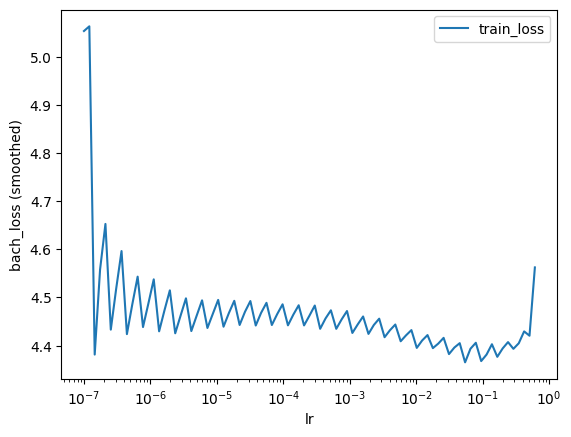

In [86]:
lrfinder = model.lr_finder(x_train, y_train, tolerance=10)
_ = lrfinder.plot()

In [87]:
lrfinder.get_best_lr()

np.float64(0.005462277217684369)

In [88]:
model.optimizer.set_lr(0.01)

In [89]:
epochs = 512
callbacks = [tt.callbacks.EarlyStopping()]
verbose = True

In [90]:
batch_size = 256

In [91]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val, val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.4038,	val_loss: 4.3075
1:	[0s / 0s],		train_loss: 4.1633,	val_loss: 4.3290
2:	[0s / 0s],		train_loss: 4.2252,	val_loss: 4.3299
3:	[0s / 0s],		train_loss: 4.2122,	val_loss: 4.2801
4:	[0s / 0s],		train_loss: 4.1413,	val_loss: 4.2741
5:	[0s / 0s],		train_loss: 4.2088,	val_loss: 4.2787
6:	[0s / 0s],		train_loss: 4.2098,	val_loss: 4.2834
7:	[0s / 0s],		train_loss: 4.1524,	val_loss: 4.2839
8:	[0s / 0s],		train_loss: 4.1982,	val_loss: 4.2850
9:	[0s / 0s],		train_loss: 4.1983,	val_loss: 4.2835
10:	[0s / 0s],		train_loss: 4.1664,	val_loss: 4.2857
11:	[0s / 0s],		train_loss: 4.2205,	val_loss: 4.2829
12:	[0s / 0s],		train_loss: 4.2390,	val_loss: 4.2756
13:	[0s / 0s],		train_loss: 4.2310,	val_loss: 4.2760
14:	[0s / 0s],		train_loss: 4.2560,	val_loss: 4.2805
CPU times: user 255 ms, sys: 618 ms, total: 873 ms
Wall time: 179 ms


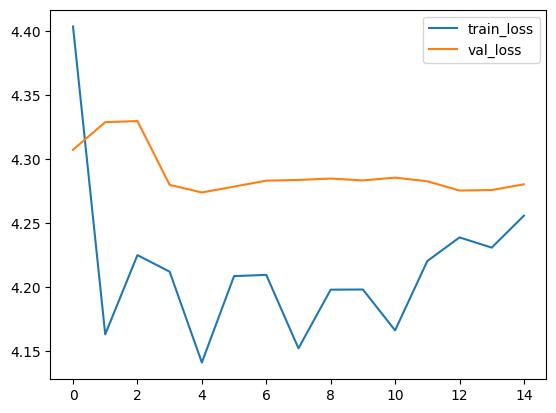

In [92]:
_ = log.plot()

In [93]:
model.partial_log_likelihood(*val).mean()

np.float32(-4.76166)

## Prediction

In [94]:
_ = model.compute_baseline_hazards()

In [95]:
surv = model.predict_surv_df(x_test)

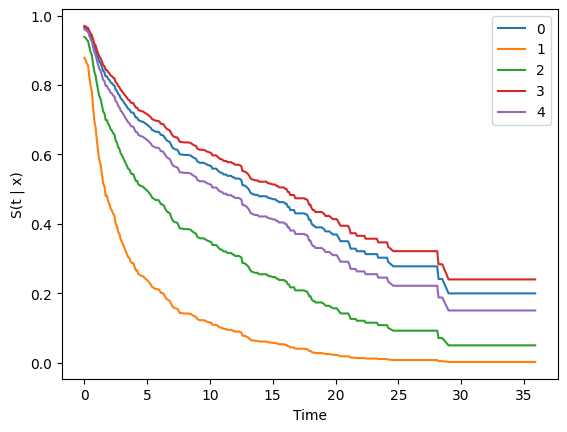

In [96]:
surv.iloc[:, :5].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

## Evaluation


In [97]:
ev = EvalSurv(surv, time_tests, status_tests, censor_surv='km')

In [98]:
ev.concordance_td()

0.578986386305432

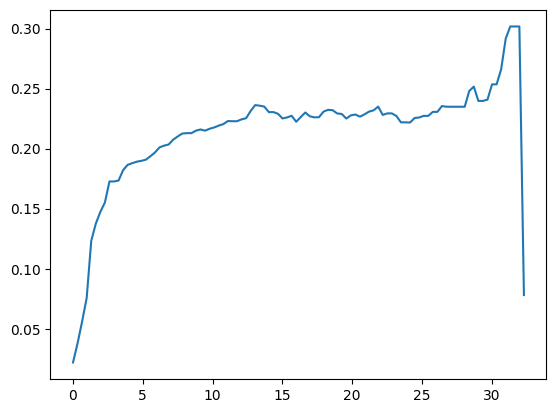

In [99]:
time_grid = np.linspace(time_tests.min(), time_tests.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [100]:
ev.integrated_brier_score(time_grid)

np.float64(0.2154701616620902)

In [101]:
ev.integrated_nbll(time_grid)

np.float64(0.6148400365050007)

<Axes: >

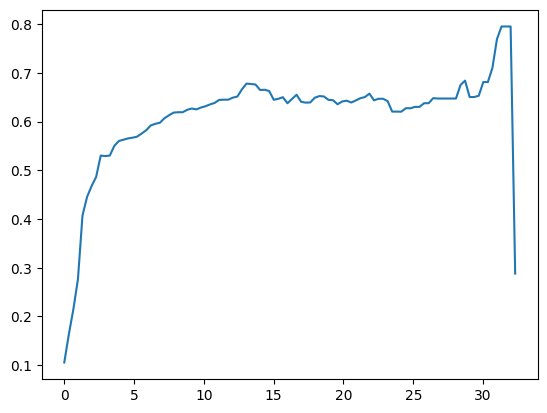

In [102]:
ev.nbll(time_grid).plot()